# Replay BO with BoTorch backend

Takes the observations (`df_results`) collected during the live run and re-runs the BO acquisition pipeline **offline** using the BoTorch backend (`OscillationBOBoTorch`) instead of gpax.

BoTorch uses noisy EI (`qLogNoisyExpectedImprovement`) natively, which handles the sparse-outlier objective shape without the numerical collapse we saw in gpax's plug-in EI.

In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from faro.agents.bo_optimization import BO_Parameter, BO_Covariate, BO_Objective
from faro.agents.bo_botorch import BOptBoTorch

# Path to the completed live run
RUN_PATH = r"E:\Alex\2026-04-10_bo_erk_oscillation_v3"
CHECKPOINT_DIR = os.path.join(RUN_PATH, "checkpoints")

ckpts = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "bo_results_phase_*.parquet")))
df_all = pd.read_parquet(ckpts[-1])
print(f"Total observations: {len(df_all)}")
print(df_all.head())

Total observations: 141
   stim_exposure  ramp  n_cells  optortk_expression  baseline_cnr  \
0           75.0  15.0     48.0         2244.776787      0.802874   
1           75.0  15.0     22.0         3300.776786      0.864222   
2           75.0  15.0     53.0         2284.822188      0.758225   
3           75.0  15.0     32.0         2083.366693      0.845478   
4           75.0  15.0     27.0         2654.958429      0.852516   

   frac_oscillating  
0          0.000000  
1          0.000000  
2          0.000000  
3          0.062500  
4          0.037037  


## Rebuild a BoTorch BO agent offline

In [6]:
bo_params = [
    BO_Parameter(name="stim_exposure", bounds=(50.0, 500.0), spacing=25.0),
    BO_Parameter(name="ramp", bounds=(0.0, 20.0), spacing=5.0),
]
bo_covariates = [
    BO_Covariate(name="n_cells"),
    BO_Covariate(name="optortk_expression"),
    BO_Covariate(name="baseline_cnr"),
]
bo_objective = BO_Objective(name="frac_oscillating", goal="maximize")


class _ReplayBoTorch(BOptBoTorch):
    def _create_events_for_cycle(self, parameters):
        raise NotImplementedError("offline replay")

    def _preprocess_results(self, tracks):
        return pd.DataFrame()


agent = _ReplayBoTorch(
    storage_path=os.path.join(RUN_PATH, "replay_botorch"),
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=10,
    n_conditions_per_iter=2,
    n_initial_phases=2,
    acquisition_function="ei",
    n_cov_samples=40,
    ei_xi=0.1,
    ei_xi_final=0.01,
    ei_xi_decay_fraction=0.7,
    verbose=False,
)
os.makedirs(agent.storage_path, exist_ok=True)
agent.df_results = df_all.copy()
print(f"Agent ready with {len(agent.df_results)} observations")

Agent ready with 141 observations


## Ask the BoTorch BO what it would pick next

In [7]:
agent.iteration = agent.n_iterations - 1

picks = agent._select_batch_parameters(
    agent.df_results, n_conditions=agent.n_conditions_per_iter
)
print("Next conditions the BoTorch BO would measure:")
for i, p in enumerate(picks):
    print(f"  {i}: {p}")

  Fitting SingleTaskGP on 141 observations (5-D)...
  Predicting 3800 points (95 grid x 40 cov samples)...
  [reusing cached GP fit from earlier in this batch]
  Predicting 3760 points (94 grid x 40 cov samples)...
Next conditions the BoTorch BO would measure:
  0: {'stim_exposure': np.float64(300.0), 'ramp': np.float64(10.0)}
  1: {'stim_exposure': np.float64(300.0), 'ramp': np.float64(0.0)}


## Visualise the GP landscape + acquisition (BoTorch backend)

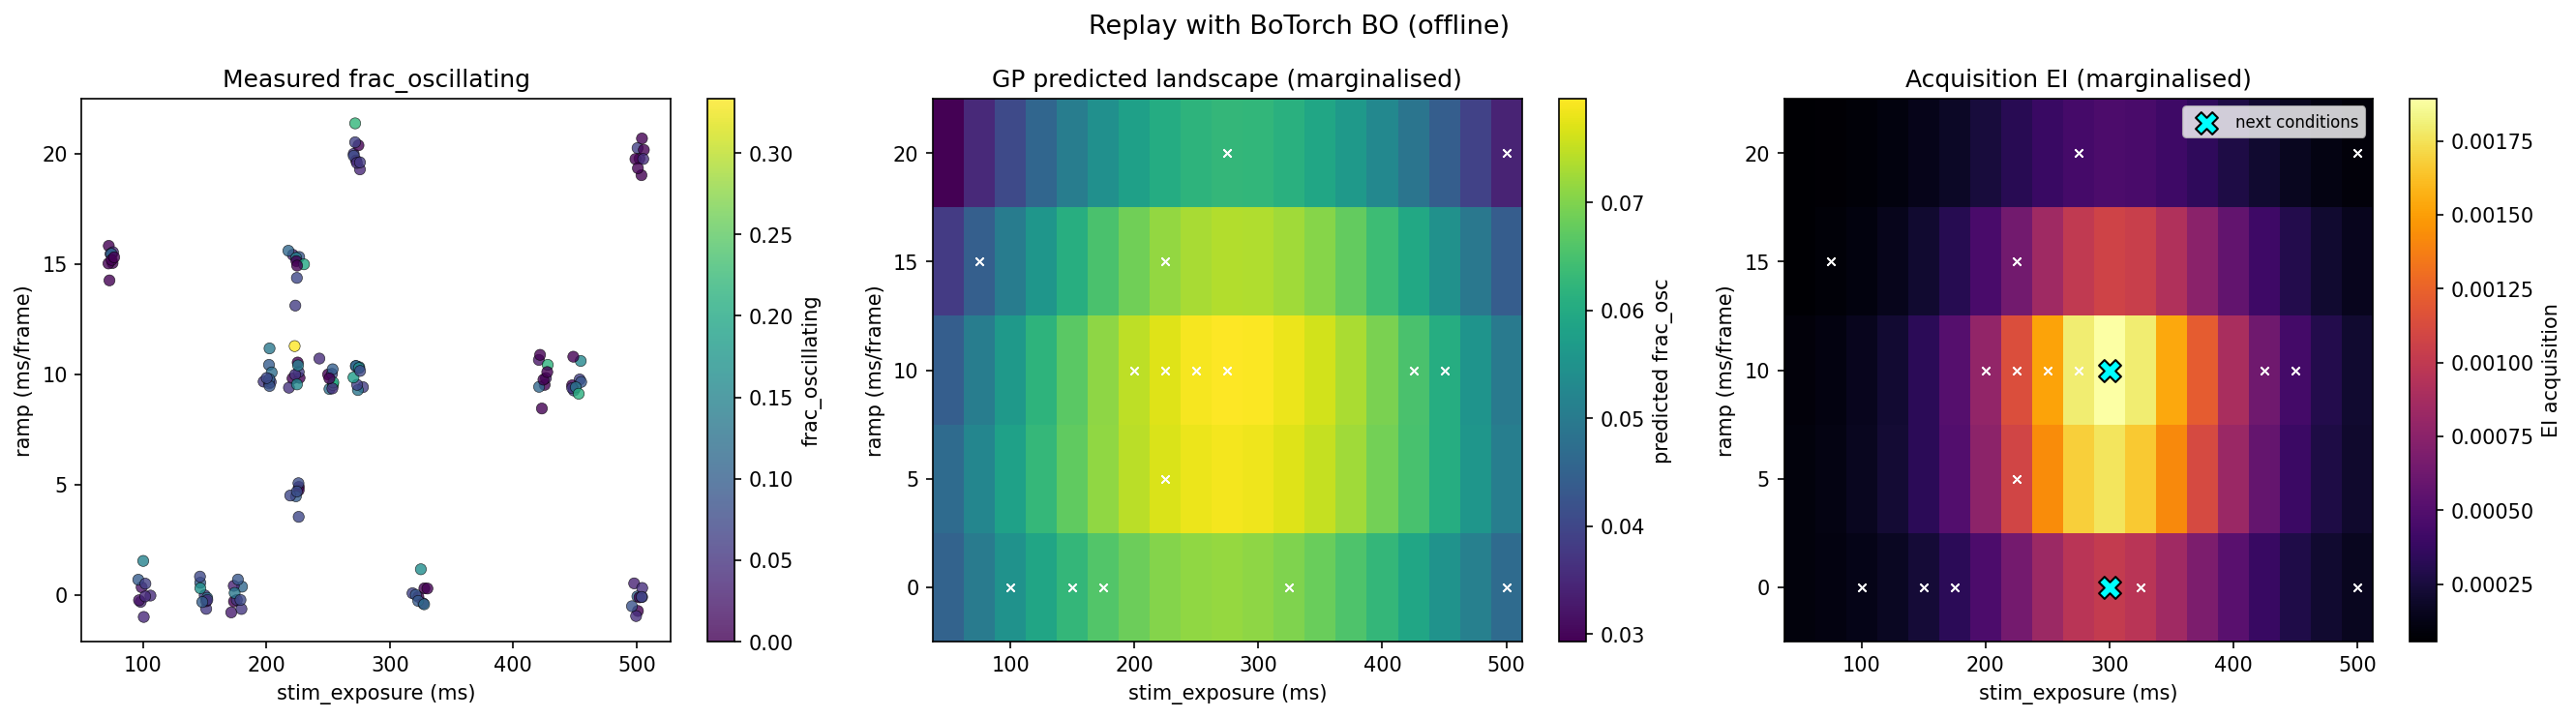

In [8]:
import torch

ctx = agent._last_plot_context
gp_model = ctx["gp_model"]
acq_values = np.asarray(ctx["acq_values_total"])
acq_name = ctx["acquisition_used"].upper()

x_total = agent.x_total_linespace.copy()
unique_x1 = np.unique(x_total[:, 0])
unique_x2 = np.unique(x_total[:, 1])
n_ctrl = len(unique_x1) * len(unique_x2)
ctrl_grid = np.array([[x1, x2] for x1 in unique_x1 for x2 in unique_x2])

cov_cols = [c.name for c in agent.bo_covariates]
cov_vals = df_all[cov_cols].to_numpy(dtype=float)
n_cov_samples = 50
rng = np.random.default_rng(0)
cov_samples = cov_vals[rng.integers(0, cov_vals.shape[0], size=n_cov_samples)]

x_full = np.hstack(
    [
        np.repeat(ctrl_grid, n_cov_samples, axis=0),
        np.tile(cov_samples, (n_ctrl, 1)),
    ]
)

x_transformed = agent._apply_log_transforms(x_full)
X_pred = torch.tensor(x_transformed, dtype=torch.double)

with torch.no_grad():
    posterior = gp_model.posterior(X_pred)
    y_pred = posterior.mean.squeeze(-1).numpy()

if agent.objective_metric.log_scale:
    y_pred = np.exp(y_pred)

y_pred_marg = y_pred.reshape(n_ctrl, n_cov_samples).mean(axis=1)
X_mesh, Y_mesh = np.meshgrid(unique_x1, unique_x2, indexing="ij")
y_2d = y_pred_marg.reshape(len(unique_x1), len(unique_x2))

# Pad acq to full grid
if len(acq_values) != n_ctrl:
    acq_full = np.zeros(n_ctrl)
    for j, pt in enumerate(ctx["x_unmeasured_at_computation"]):
        diffs = np.abs(x_total - pt).sum(axis=1)
        acq_full[int(np.argmin(diffs))] = (
            float(acq_values[j]) if j < len(acq_values) else 0.0
        )
    acq_values = acq_full
acq_2d = acq_values.reshape(len(unique_x1), len(unique_x2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)
fig.suptitle("Replay with BoTorch BO (offline)", fontsize=13)

# 1. Measured points
sc = axes[0].scatter(
    df_all["stim_exposure"] + rng.normal(0, 3, len(df_all)),
    df_all["ramp"] + rng.normal(0, 0.5, len(df_all)),
    c=df_all["frac_oscillating"],
    cmap="viridis",
    s=30,
    edgecolors="k",
    linewidths=0.3,
    alpha=0.8,
)
axes[0].set_xlabel("stim_exposure (ms)")
axes[0].set_ylabel("ramp (ms/frame)")
axes[0].set_title("Measured frac_oscillating")
fig.colorbar(sc, ax=axes[0], label="frac_oscillating")

# 2. GP landscape
im1 = axes[1].pcolormesh(X_mesh, Y_mesh, y_2d, cmap="viridis", shading="auto")
fig.colorbar(im1, ax=axes[1], label="predicted frac_osc")
axes[1].scatter(
    df_all["stim_exposure"],
    df_all["ramp"],
    c="white",
    s=15,
    alpha=0.6,
    marker="x",
    linewidths=0.8,
)
axes[1].set_xlabel("stim_exposure (ms)")
axes[1].set_ylabel("ramp (ms/frame)")
axes[1].set_title("GP predicted landscape (marginalised)")

# 3. Acquisition + picks
im2 = axes[2].pcolormesh(X_mesh, Y_mesh, acq_2d, cmap="inferno", shading="auto")
fig.colorbar(im2, ax=axes[2], label=f"{acq_name} acquisition")
axes[2].scatter(
    df_all["stim_exposure"],
    df_all["ramp"],
    c="white",
    s=15,
    alpha=0.6,
    marker="x",
    linewidths=0.8,
)
picks_arr = np.array([[p["stim_exposure"], p["ramp"]] for p in picks])
axes[2].scatter(
    picks_arr[:, 0],
    picks_arr[:, 1],
    c="cyan",
    s=120,
    marker="X",
    edgecolors="k",
    linewidths=1.0,
    zorder=10,
    label="next conditions",
)
axes[2].legend(loc="upper right", fontsize=8)
axes[2].set_xlabel("stim_exposure (ms)")
axes[2].set_ylabel("ramp (ms/frame)")
axes[2].set_title(f"Acquisition {acq_name} (marginalised)")

plt.tight_layout()
plt.show()